In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.dates import date2num 
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy import stats
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

In [105]:
# Load data
df = pd.read_csv('historical_stablecoin.csv')
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,peggedUSD,peggedEUR,peggedVAR,peggedJPY,peggedCNY,peggedUAH,peggedARS,peggedGBP,peggedCAD,peggedCHF,peggedAUD,peggedREAL
0,2021-01-01,28286859559,3871222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,28825490421,4272046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,28995680791,5510939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,29328599685,5971796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,29771217419,7836686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
# Detect first non null date for each column
first_dates = {}
for col in df.columns[1:]:  # Skip Date column
    non_null = df[col].notna()
    if non_null.any():
        idx = non_null.idxmax()
        first_dates[col] = df.loc[idx, 'date']
    else:
        first_dates[col] = pd.NaT

launch_df = pd.DataFrame([{'currency': k, 'launch_date': v} for k, v in first_dates.items()])
launch_df = launch_df.sort_values('launch_date').reset_index(drop=True)

print("Launch Dates of Stablecoins:")
print(launch_df)

Launch Dates of Stablecoins:
      currency launch_date
0    peggedUSD  2021-01-01
1    peggedEUR  2021-01-01
2    peggedVAR  2021-02-14
3    peggedJPY  2023-08-10
4    peggedCNY  2023-09-01
5    peggedUAH  2023-10-04
6    peggedARS  2023-10-06
7    peggedGBP  2023-11-23
8    peggedCAD  2023-12-08
9    peggedCHF  2024-01-25
10   peggedAUD  2024-03-06
11  peggedREAL  2024-07-03


# EDA

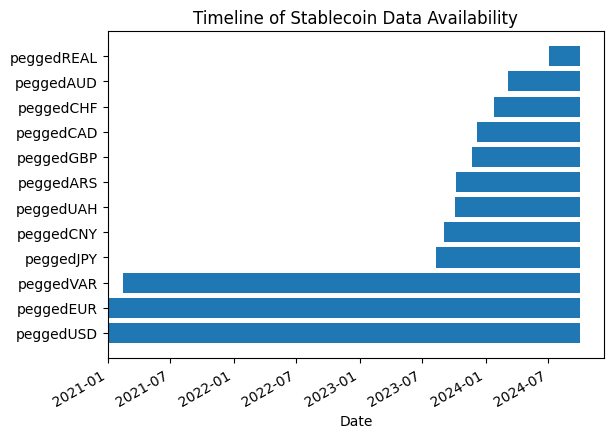

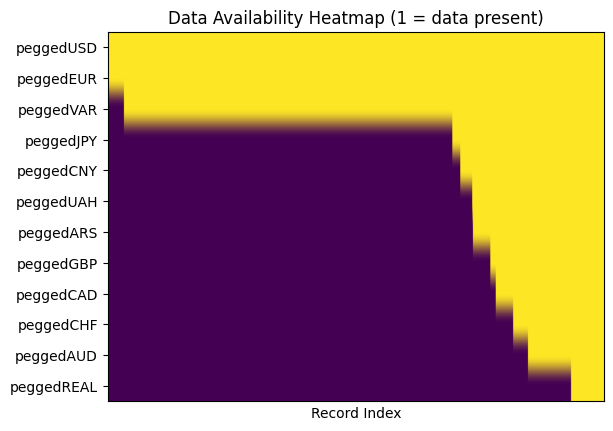

In [107]:
# Plot horizontal timeline of launches
last_date = df['date'].max()
starts = date2num(launch_df['launch_date'])
widths = date2num(last_date) - starts

plt.figure()
plt.barh(launch_df['currency'], widths, left=starts)
plt.xlabel('Date')
plt.title('Timeline of Stablecoin Data Availability')
plt.gca().xaxis_date()
plt.gcf().autofmt_xdate()
plt.show()

# Plot heatmap of data availability
availability = df.set_index('date')[launch_df['currency']].notna().T.astype(int)

plt.figure()
plt.imshow(availability, aspect='auto')
plt.yticks(range(len(availability.index)), availability.index)
plt.xticks([], [])
plt.xlabel('Record Index')
plt.title('Data Availability Heatmap (1 = data present)')
plt.show()

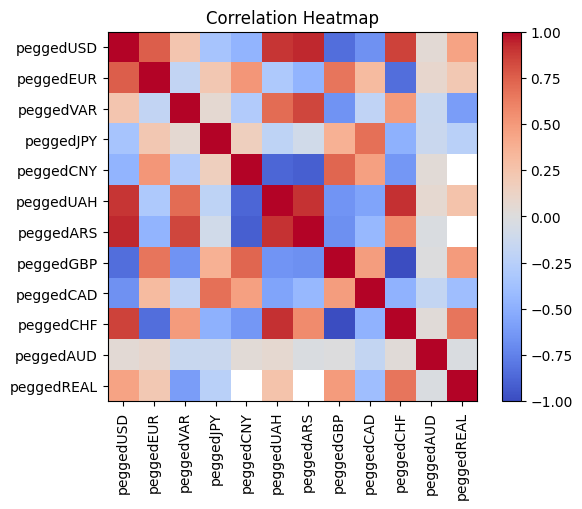

In [108]:
# Correlation Heatmap 
plt.figure()
corr = df.drop(columns='date').corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title('Correlation Heatmap')
plt.show()

# Deteksi Anomali

In [109]:
# Get a list of all stablecoin columns
coins = df.columns.drop('date')

# Create monthly data for analysis
monthly = df.set_index('date')['peggedUSD'].resample('M').last().dropna()
monthly_all = df.set_index('date')[coins].resample('M').last().dropna(how='all')

# Create daily differences for spike detection
df_diff = df.set_index('date').diff()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_62763/1016505511.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['peggedUSD'].resample('M').last().dropna()
/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_62763/1016505511.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_all = df.set_index('date')[coins].resample('M').last().dropna(how='all')


In [110]:
# Anomali supply (Z-score > 3)
z_supply     = (monthly - monthly.mean()) / monthly.std()
supply_anoms = monthly[abs(z_supply) > 3]

# Anomali growth rate (Z-score > 3)
growth       = monthly.pct_change().dropna() * 100
z_growth     = (growth - growth.mean()) / growth.std()
growth_anoms = growth[abs(z_growth) > 3]

# Print
print("=== Supply Anomalies (Z>3) ===")
print(supply_anoms.to_string())

print("\n=== Growth Anomalies (Z>3) ===")
print(growth_anoms.to_string())

=== Supply Anomalies (Z>3) ===
date
2021-01-31    37189036128
Freq: ME

=== Growth Anomalies (Z>3) ===
date
2021-02-28    38.646913
2021-04-30    35.157105


## try new

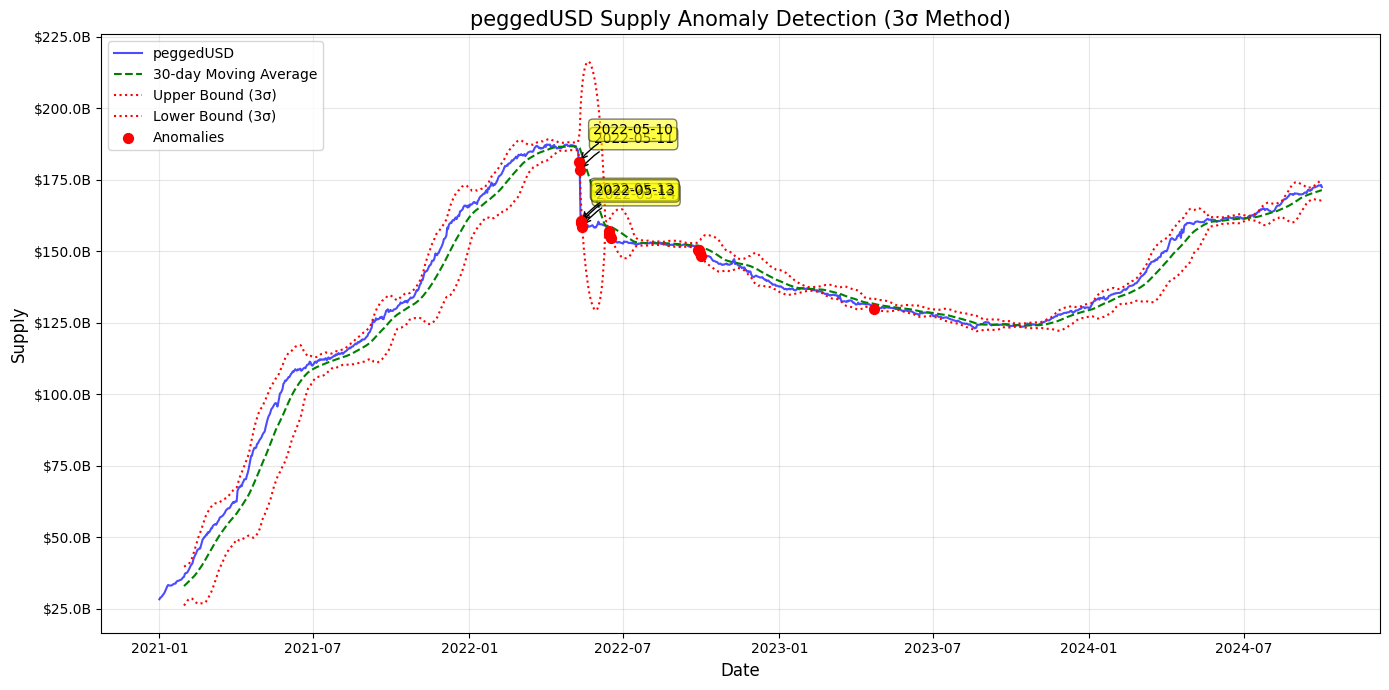

In [111]:
# 1. Enhanced Anomaly Detection Visualization for peggedUSD
plt.figure(figsize=(14, 7))

# Calculate rolling mean and standard deviation
window = 30
rolling_mean = df_indexed['peggedUSD'].rolling(window=window).mean()
rolling_std = df_indexed['peggedUSD'].rolling(window=window).std()

# Calculate upper and lower bounds (3 standard deviations)
upper_bound = rolling_mean + (rolling_std * 3)
lower_bound = rolling_mean - (rolling_std * 3)

# Identify anomalies - now everything has the same index
anomalies = df_indexed[((df_indexed['peggedUSD'] > upper_bound) | 
                      (df_indexed['peggedUSD'] < lower_bound)) &
                      (df_indexed['peggedUSD'].notnull())]

# Plot the data
plt.plot(df_indexed.index, df_indexed['peggedUSD'], label='peggedUSD', color='blue', alpha=0.7)
plt.plot(rolling_mean.index, rolling_mean, label=f'{window}-day Moving Average', color='green', linestyle='--')
plt.plot(upper_bound.index, upper_bound, label='Upper Bound (3σ)', color='red', linestyle=':')
plt.plot(lower_bound.index, lower_bound, label='Lower Bound (3σ)', color='red', linestyle=':')
plt.scatter(anomalies.index, anomalies['peggedUSD'], color='red', label='Anomalies', s=50, zorder=5)

# Mark and annotate the top 5 most significant anomalies
if len(anomalies) > 0:
    # Calculate how far each anomaly is from the rolling mean
    anomalies_mean_idx = anomalies.index.intersection(rolling_mean.index)
    if len(anomalies_mean_idx) > 0:
        distance = abs(anomalies.loc[anomalies_mean_idx, 'peggedUSD'] - 
                    rolling_mean.loc[anomalies_mean_idx])
        
        # Get top 5 anomalies (or fewer if there are less than 5)
        num_annotations = min(5, len(distance))
        top_idx = distance.nlargest(num_annotations).index
        
        for idx in top_idx:
            plt.annotate(f"{idx.strftime('%Y-%m-%d')}", 
                        xy=(idx, anomalies.loc[idx, 'peggedUSD']),
                        xytext=(10, 20),
                        textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black'),
                        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

plt.title('peggedUSD Supply Anomaly Detection (3σ Method)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Supply', fontsize=12)

# Format the y-axis to show billions
def billions(x, pos):
    return f'${x/1e9:.1f}B'
plt.gca().yaxis.set_major_formatter(FuncFormatter(billions))

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('usd_anomalies.png', dpi=300)
plt.show()


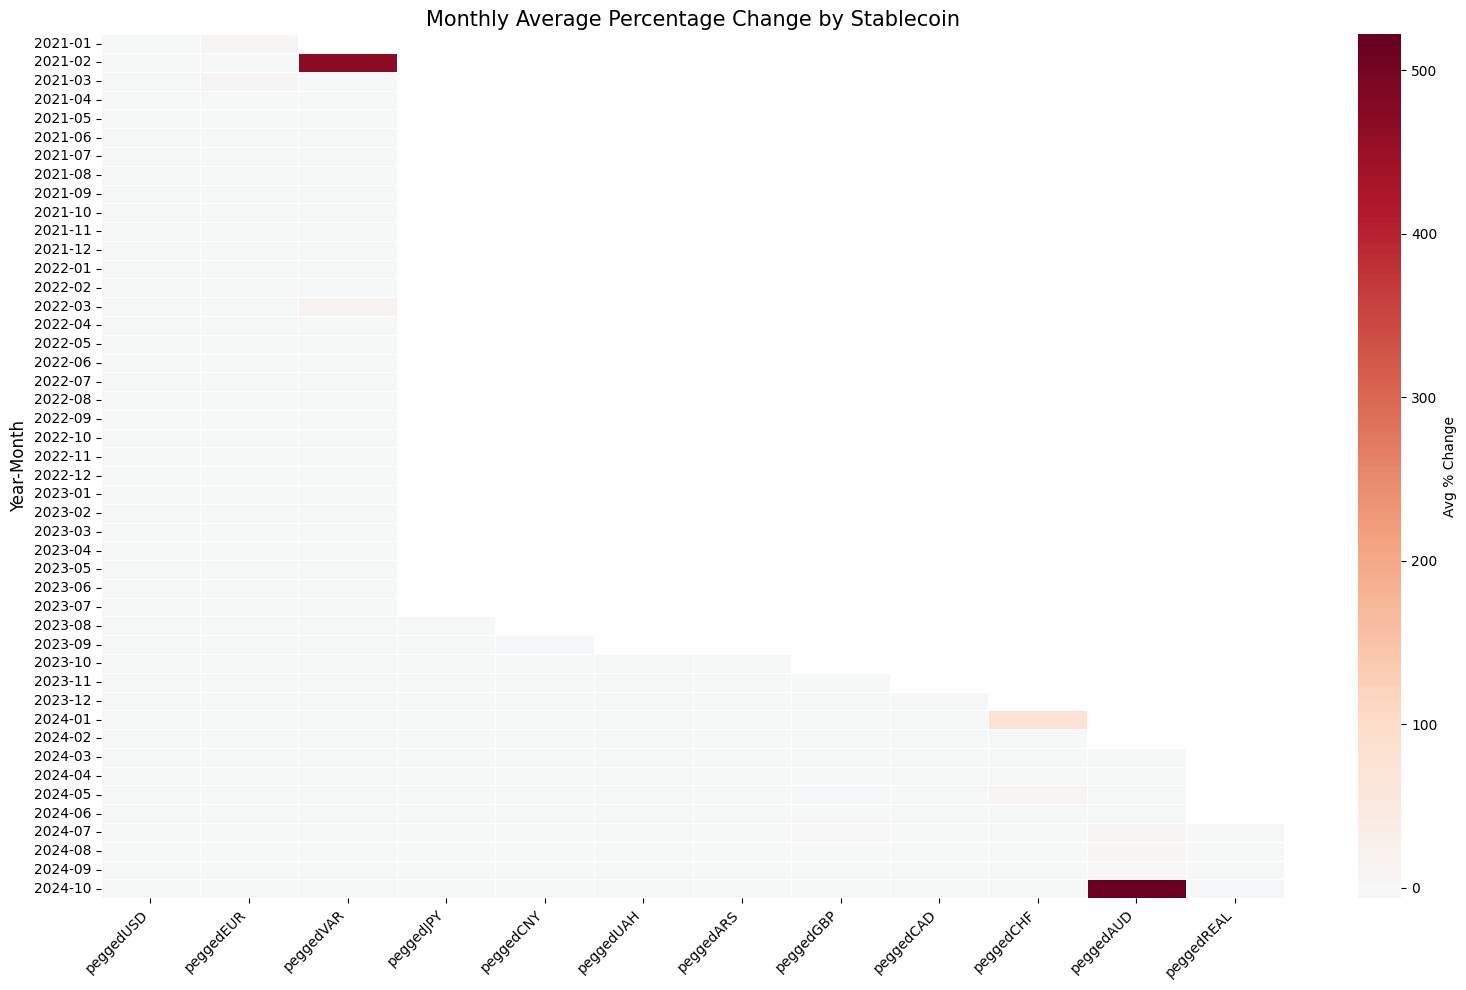

In [112]:
# Daily Percentage Change Heatmap
# Calculate daily percentage changes
pct_changes = df_indexed[coins].pct_change() * 100

# Create a DataFrame with year and month as indices for the heatmap
def get_month_year(date):
    return date.strftime('%Y-%m')

# Filter to only include columns with sufficient non-null data
active_coins = [coin for coin in coins if pct_changes[coin].count() > 30]

if active_coins:
    monthly_pct = pct_changes[active_coins].copy()
    monthly_pct['month_year'] = [get_month_year(idx) for idx in monthly_pct.index]
    
    # Group by month-year and calculate mean
    monthly_avg_change = monthly_pct.groupby('month_year')[active_coins].mean()
    
    # Convert to a pivot table for visualization
    plt.figure(figsize=(16, 10))
    sns.heatmap(monthly_avg_change, cmap='RdBu_r', center=0, 
                linewidths=0.5, cbar_kws={'label': 'Avg % Change'})
    plt.title('Monthly Average Percentage Change by Stablecoin', fontsize=15)
    plt.ylabel('Year-Month', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('monthly_pct_change_heatmap.png', dpi=300)
    plt.show()

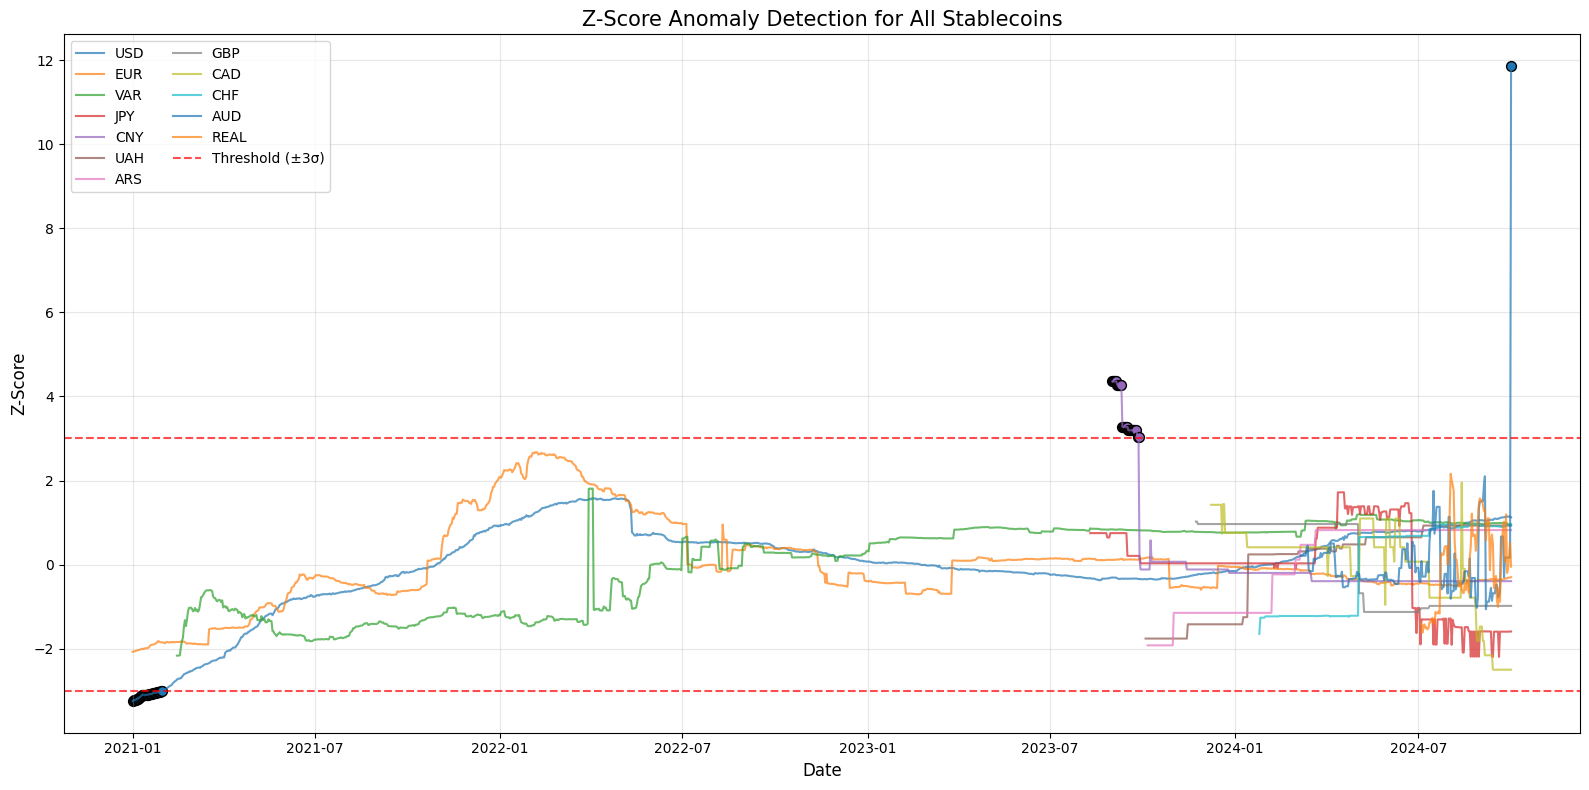

In [113]:
# Z-Score Based Anomaly Detection for All Stablecoins
plt.figure(figsize=(16, 8))

# Calculate Z-scores for each coin
z_scores = {}
anomalies_by_coin = {}

# Only analyze coins with sufficient data
for coin in coins:
    coin_data = df_indexed[coin].dropna()
    if len(coin_data) > 30:  # At least 30 data points
        # Calculate Z-score
        mean_val = coin_data.mean()
        std_val = coin_data.std()
        if std_val > 0:  # Avoid division by zero
            z_scores[coin] = (coin_data - mean_val) / std_val
            
            # Mark points beyond 3 standard deviations as anomalies
            anomalies_by_coin[coin] = coin_data[abs(z_scores[coin]) > 3]

# Prepare the plot
anomaly_count = sum(len(anoms) for anoms in anomalies_by_coin.values())

if anomaly_count > 0:
    # Set up color cycle for different coins
    colors = plt.cm.tab10.colors
    
    # Main plot
    for i, coin in enumerate(z_scores.keys()):
        color = colors[i % len(colors)]
        plt.plot(z_scores[coin].index, z_scores[coin], 
                 label=coin.replace('pegged', ''), color=color, alpha=0.7)
        
        # Plot anomalies for this coin
        if coin in anomalies_by_coin and len(anomalies_by_coin[coin]) > 0:
            anomaly_indices = anomalies_by_coin[coin].index
            plt.scatter(anomaly_indices, z_scores[coin].loc[anomaly_indices], 
                       color=color, s=50, edgecolor='black')
    
    # Add threshold lines
    plt.axhline(y=3, color='r', linestyle='--', alpha=0.7, label='Threshold (±3σ)')
    plt.axhline(y=-3, color='r', linestyle='--', alpha=0.7)
    
    plt.title('Z-Score Anomaly Detection for All Stablecoins', fontsize=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Z-Score', fontsize=12)
    plt.legend(loc='best', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('z_score_all_coins.png', dpi=300)
    plt.show()

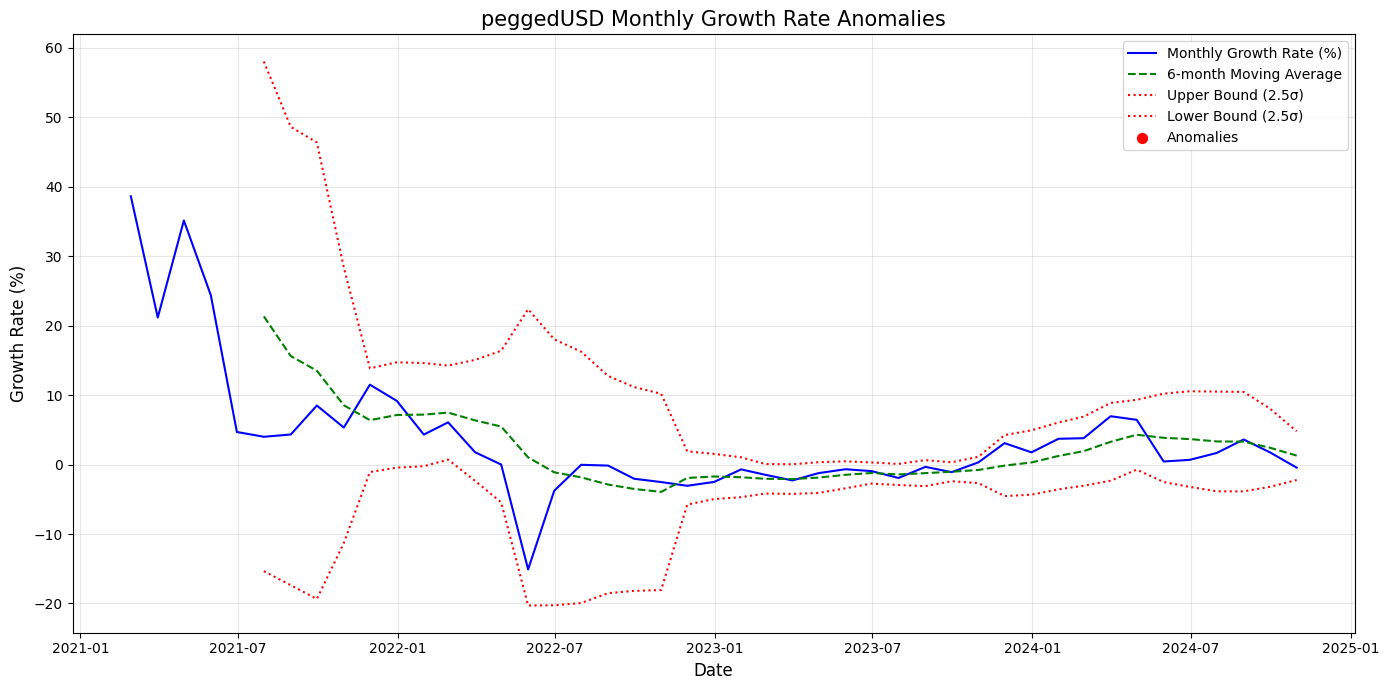

In [114]:
# Anomaly Detection in Growth Rates
plt.figure(figsize=(14, 7))

# Calculate monthly growth rates
growth_rates = monthly.pct_change() * 100

# Calculate rolling statistics for growth rates
window = 6  # 6-month window
rolling_mean_growth = growth_rates.rolling(window=window).mean()
rolling_std_growth = growth_rates.rolling(window=window).std()

# Define bounds for anomalies (2.5 standard deviations for growth rates)
upper_bound_growth = rolling_mean_growth + (2.5 * rolling_std_growth)
lower_bound_growth = rolling_mean_growth - (2.5 * rolling_std_growth)

# Identify anomalies
growth_anomalies = growth_rates[((growth_rates > upper_bound_growth) | 
                                 (growth_rates < lower_bound_growth)) &
                                 (growth_rates.notnull())]

# Plot
plt.plot(growth_rates.index, growth_rates, label='Monthly Growth Rate (%)', color='blue')
plt.plot(rolling_mean_growth.index, rolling_mean_growth, 
         label=f'{window}-month Moving Average', color='green', linestyle='--')
plt.plot(upper_bound_growth.index, upper_bound_growth, 
         label='Upper Bound (2.5σ)', color='red', linestyle=':')
plt.plot(lower_bound_growth.index, lower_bound_growth, 
         label='Lower Bound (2.5σ)', color='red', linestyle=':')

# Mark anomalies
plt.scatter(growth_anomalies.index, growth_anomalies, 
            color='red', label='Anomalies', s=50)

# Annotate significant anomalies
if len(growth_anomalies) > 0:
    # Get top 3 anomalies (by absolute value)
    top_growth_anomalies = growth_anomalies.abs().nlargest(3)
    
    for idx, value in top_growth_anomalies.items():
        plt.annotate(f"{idx.strftime('%Y-%m')}: {growth_anomalies[idx]:.1f}%", 
                    xy=(idx, growth_anomalies[idx]),
                    xytext=(10, 20),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'),
                    bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

plt.title('peggedUSD Monthly Growth Rate Anomalies', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('growth_rate_anomalies.png', dpi=300)
plt.show()

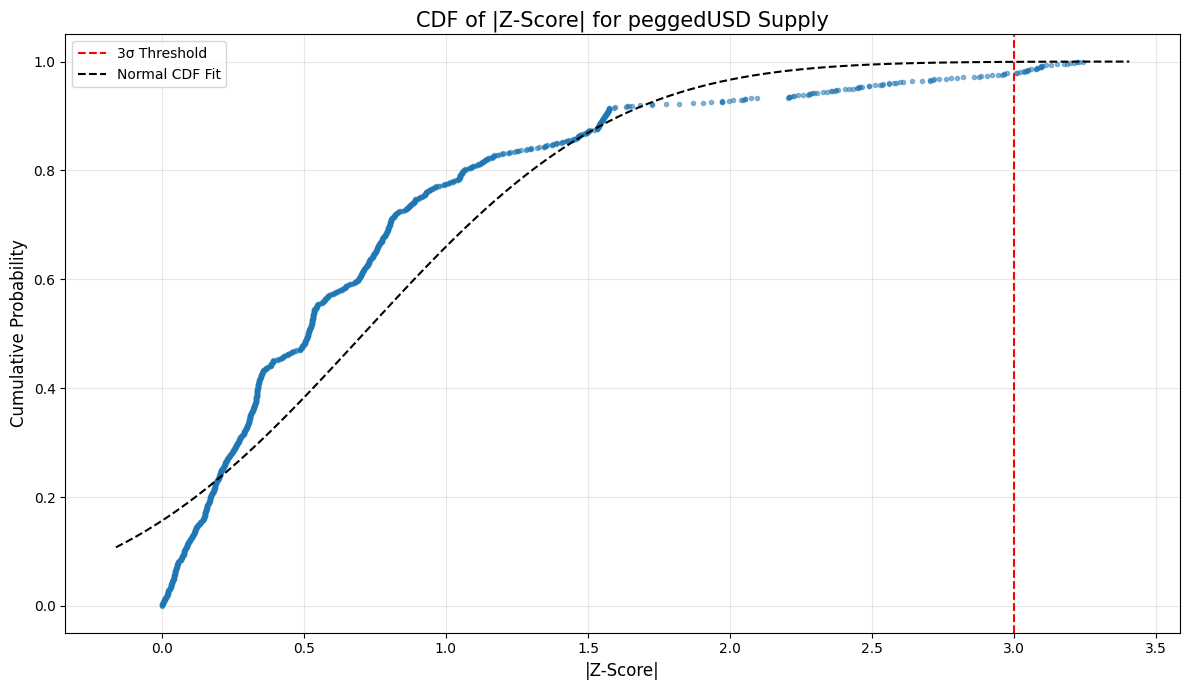

In [115]:
# Cumulative Distribution Function for Anomaly Score
plt.figure(figsize=(12, 7))

# Create an anomaly score based on z-scores for peggedUSD
usd_data = df_indexed['peggedUSD'].dropna()
if len(usd_data) > 0 and usd_data.std() > 0:  # Check for valid data
    z_usd = abs((usd_data - usd_data.mean()) / usd_data.std())

    # Sort the z-scores
    sorted_z = np.sort(z_usd.values)
    cumulative_prob = np.arange(1, len(sorted_z) + 1) / len(sorted_z)

    # Plot CDF
    plt.plot(sorted_z, cumulative_prob, marker='.', linestyle='none', alpha=0.5)
    plt.axvline(x=3, color='r', linestyle='--', label='3σ Threshold')

    # Fit a normal distribution
    fit_mean, fit_std = stats.norm.fit(z_usd)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.cdf(x, fit_mean, fit_std)
    plt.plot(x, p, 'k', linestyle='--', label='Normal CDF Fit')

    plt.title('CDF of |Z-Score| for peggedUSD Supply', fontsize=15)
    plt.xlabel('|Z-Score|', fontsize=12)
    plt.ylabel('Cumulative Probability', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('z_score_cdf.png', dpi=300)
    plt.show()

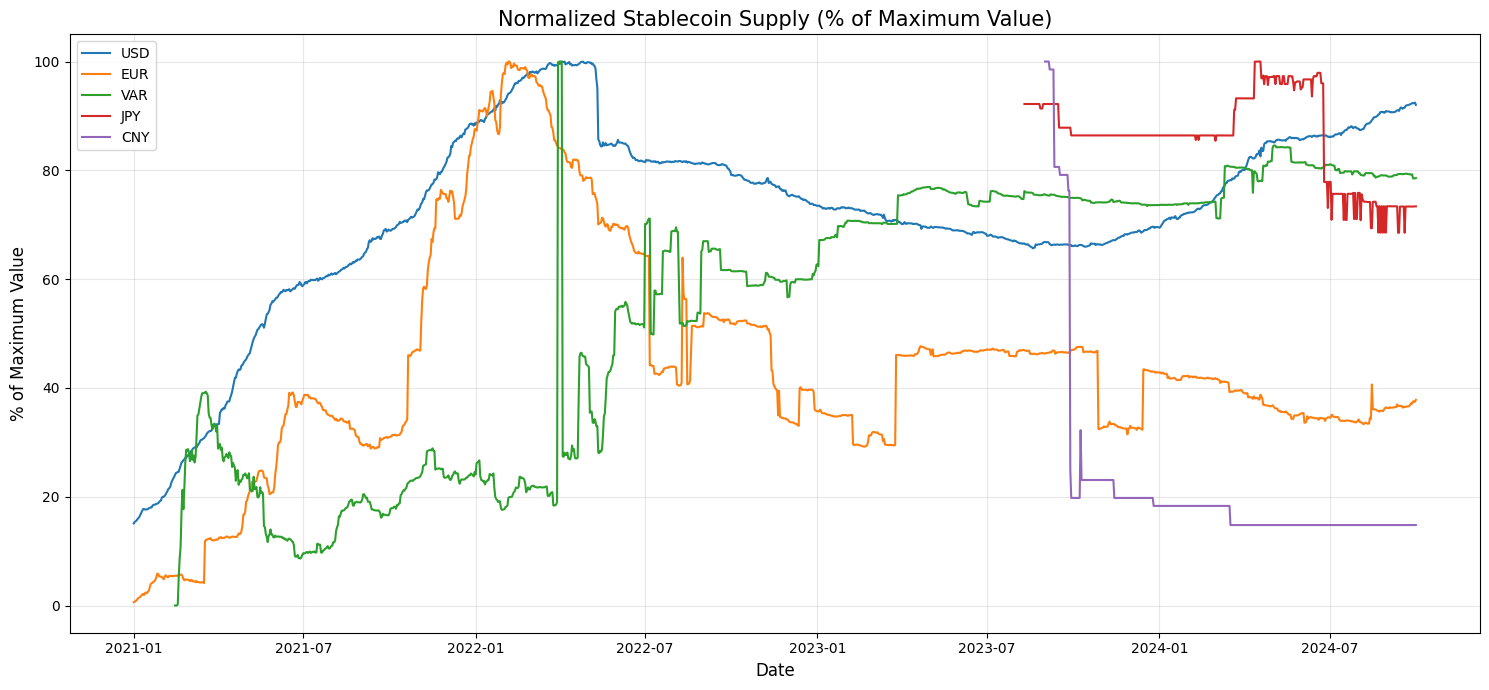

In [116]:
# Normalized Stablecoin Pattern Comparison
plt.figure(figsize=(15, 7))

# Get the stablecoins with the most data
active_coins = [coin for coin in coins if df_indexed[coin].notna().sum() > 100][:5]  # Top 5 most active

# Normalize each series for comparison (percent of max value)
normalized_series = {}
for coin in active_coins:
    data = df_indexed[coin].dropna()
    if len(data) > 0 and data.max() > 0:  # Ensure valid data
        normalized_series[coin] = data / data.max() * 100

# Plot normalized series
for coin, series in normalized_series.items():
    plt.plot(series.index, series, label=coin.replace('pegged', ''))

plt.title('Normalized Stablecoin Supply (% of Maximum Value)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('% of Maximum Value', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('normalized_supply_comparison.png', dpi=300)
plt.show()

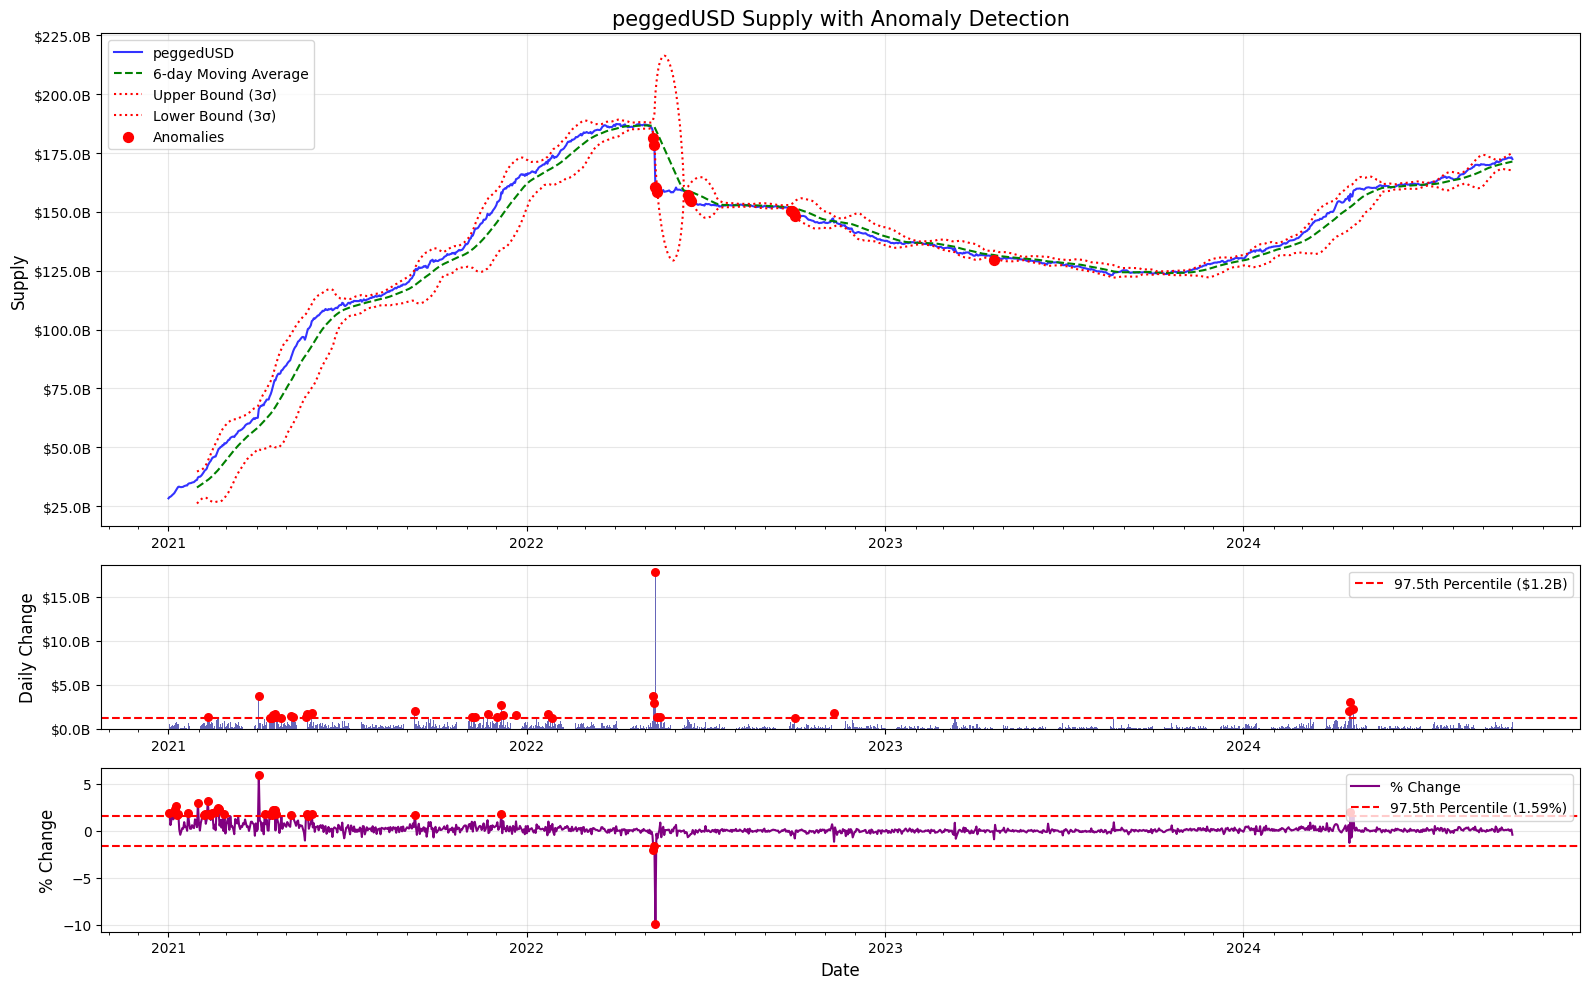

In [117]:
# Create a more detailed supply anomaly visualization with context
plt.figure(figsize=(16, 10))

# Create a subplot grid
gs = plt.GridSpec(3, 1, height_ratios=[3, 1, 1])

# Main plot - peggedUSD with anomalies
ax1 = plt.subplot(gs[0])
ax1.plot(df_indexed.index, df_indexed['peggedUSD'], 
         label='peggedUSD', color='blue', alpha=0.8)

# Add the rolling mean and bounds
ax1.plot(rolling_mean.index, rolling_mean, 
         label=f'{window}-day Moving Average', color='green', linestyle='--')
ax1.plot(upper_bound.index, upper_bound, 
         label='Upper Bound (3σ)', color='red', linestyle=':')
ax1.plot(lower_bound.index, lower_bound, 
         label='Lower Bound (3σ)', color='red', linestyle=':')

# Mark anomalies
ax1.scatter(anomalies.index, anomalies['peggedUSD'],
            color='red', label='Anomalies', s=50, zorder=5)

# Format the main plot
ax1.set_title('peggedUSD Supply with Anomaly Detection', fontsize=15)
ax1.set_ylabel('Supply', fontsize=12)
ax1.yaxis.set_major_formatter(FuncFormatter(billions))
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Second plot - Daily absolute changes
ax2 = plt.subplot(gs[1], sharex=ax1)
daily_changes = df_indexed['peggedUSD'].diff().abs()
ax2.bar(daily_changes.index, daily_changes, color='darkblue', alpha=0.6)

# Calculate threshold for large daily changes (97.5th percentile)
large_change_threshold = daily_changes.quantile(0.975)
large_changes = daily_changes[daily_changes > large_change_threshold]

# Mark large daily changes
ax2.scatter(large_changes.index, large_changes, color='red', s=30, zorder=5)

# Format the second plot
ax2.set_ylabel('Daily Change', fontsize=12)
ax2.yaxis.set_major_formatter(FuncFormatter(billions))
ax2.grid(True, alpha=0.3)
ax2.axhline(y=large_change_threshold, color='red', linestyle='--', 
           label=f'97.5th Percentile ({billions(large_change_threshold, 0)})')
ax2.legend(loc='upper right')

# Third plot - Daily percent changes
ax3 = plt.subplot(gs[2], sharex=ax1)
pct_change = df_indexed['peggedUSD'].pct_change() * 100
ax3.plot(pct_change.index, pct_change, color='purple', label='% Change')

# Calculate threshold for large percent changes (97.5th percentile of absolute values)
abs_pct_change = pct_change.abs()
large_pct_threshold = abs_pct_change.quantile(0.975)
large_pct_changes = pct_change[abs_pct_change > large_pct_threshold]

# Mark large percent changes
ax3.scatter(large_pct_changes.index, large_pct_changes, color='red', s=30, zorder=5)

# Format the third plot
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('% Change', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=large_pct_threshold, color='red', linestyle='--', label=f'97.5th Percentile ({large_pct_threshold:.2f}%)')
ax3.axhline(y=-large_pct_threshold, color='red', linestyle='--')
ax3.legend(loc='upper right')

# Format the x-axis dates for better readability
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig('detailed_anomaly_analysis.png', dpi=300)
plt.show()

23:19:56 - cmdstanpy - INFO - Chain [1] start processing
23:19:56 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


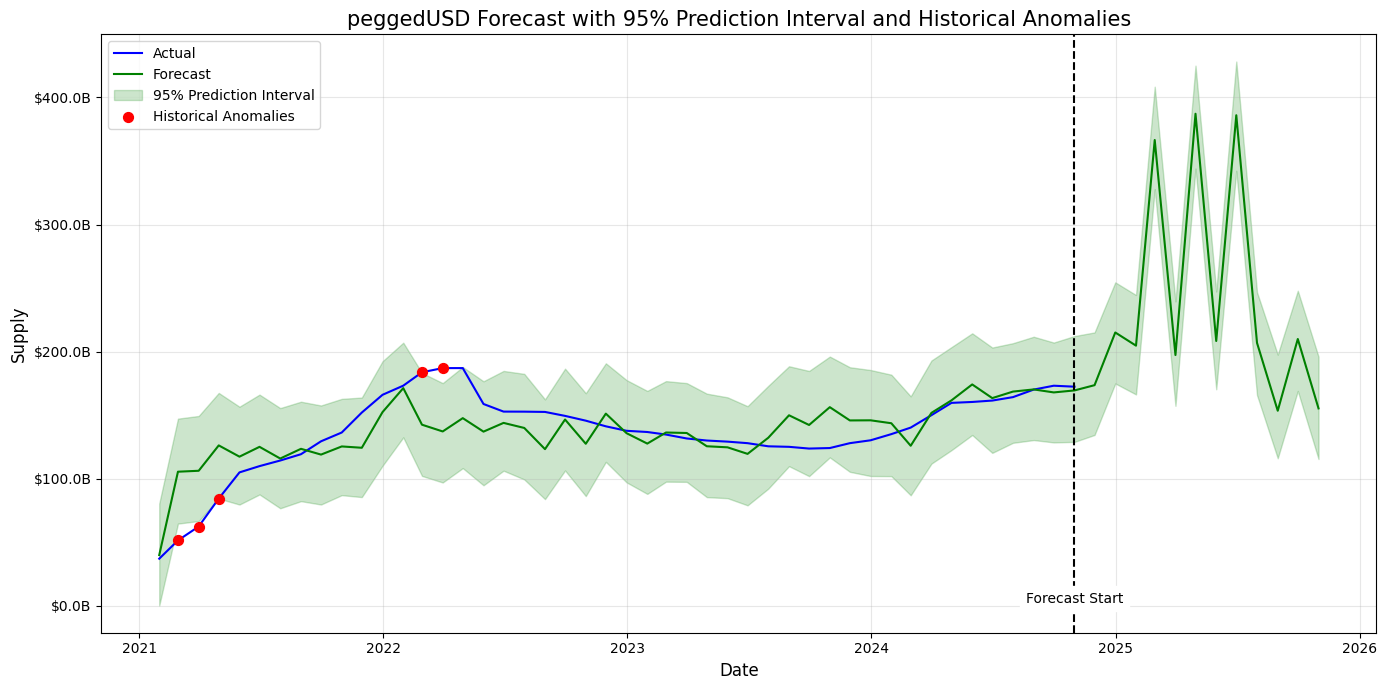

In [118]:
# Forecasting with Anomaly Bands
# Let's use Prophet to generate forecast with prediction intervals

# Create a dataframe for Prophet
prophet_df = monthly.reset_index().rename(columns={'date': 'ds', 'peggedUSD': 'y'})

# Initialize and fit the model
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95  # 95% prediction interval
)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(prophet_df)

# Make future dataframe for 12 months
future = m.make_future_dataframe(periods=12, freq='M')
forecast = m.predict(future)

# Plot the forecast with uncertainty intervals
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual values
ax.plot(prophet_df['ds'], prophet_df['y'], label='Actual', color='blue')

# Plot forecast
ax.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green', linestyle='-')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
               color='green', alpha=0.2, label='95% Prediction Interval')

# Identify historical values outside the predicted range (if forecast were made)
actual_data = prophet_df.set_index('ds')
historical_forecast = forecast[forecast['ds'].isin(actual_data.index)]
if not historical_forecast.empty:
    historical_forecast_indexed = historical_forecast.set_index('ds')
    common_idx = actual_data.index.intersection(historical_forecast_indexed.index)
    
    if len(common_idx) > 0:
        historical_anomalies = actual_data.loc[
            (actual_data.loc[common_idx, 'y'] < historical_forecast_indexed.loc[common_idx, 'yhat_lower']) | 
            (actual_data.loc[common_idx, 'y'] > historical_forecast_indexed.loc[common_idx, 'yhat_upper'])
        ]
        
        # Mark historical anomalies
        if not historical_anomalies.empty:
            ax.scatter(historical_anomalies.index, historical_anomalies['y'], 
                      color='red', s=50, zorder=5, label='Historical Anomalies')

# Format plot
ax.set_title('peggedUSD Forecast with 95% Prediction Interval and Historical Anomalies', fontsize=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Supply', fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(billions))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# Vertical line separating history from forecast
last_date = prophet_df['ds'].max()
ax.axvline(x=last_date, color='black', linestyle='--')
ax.text(last_date, ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0])*0.05, 
       'Forecast Start', ha='center', backgroundcolor='white')

plt.tight_layout()
plt.savefig('forecast_with_anomalies.png', dpi=300)
plt.show()

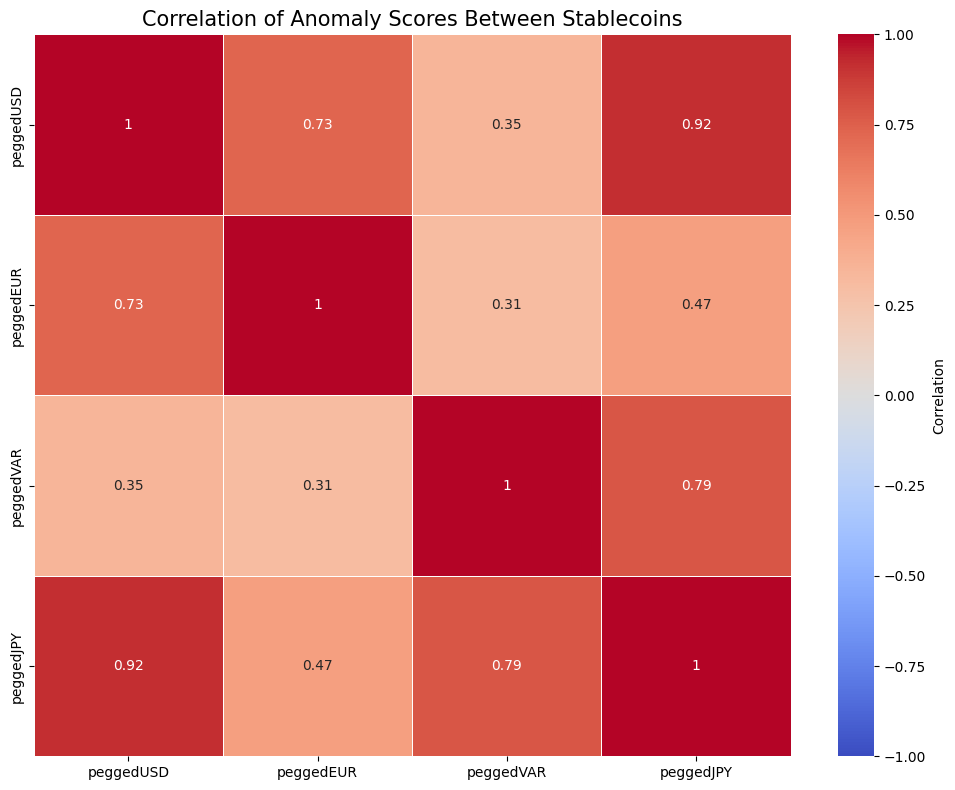

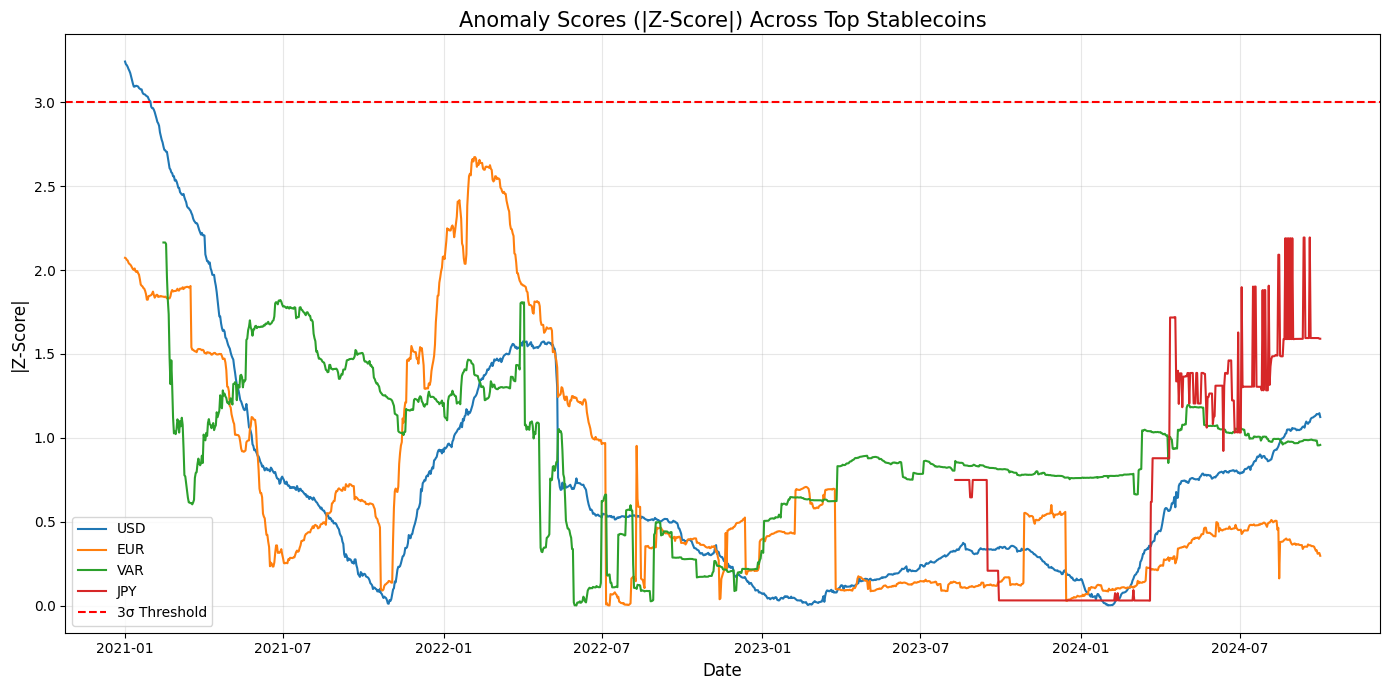

In [119]:
# Correlation Between Stablecoin Anomalies
# This will help identify if anomalies are occurring at the same time across different stablecoins

# Get the top stablecoins with sufficient data
top_coins = [coin for coin in coins if df_indexed[coin].notna().sum() > 100][:4]

if len(top_coins) >= 2:  # Need at least 2 coins for correlation
    # Calculate z-scores for each coin
    z_scores_df = pd.DataFrame(index=df_indexed.index)
    for coin in top_coins:
        coin_data = df_indexed[coin].dropna()
        if len(coin_data) > 30 and coin_data.std() > 0:  # Valid data with non-zero std
            z_scores_df[coin] = (coin_data - coin_data.mean()) / coin_data.std()
    
    # Take absolute value of z-scores
    abs_z_scores = z_scores_df.abs()
    
    # Calculate correlation between z-scores (drop NaN values)
    z_corr = abs_z_scores.corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(z_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                linewidths=0.5, cbar_kws={'label': 'Correlation'})
    plt.title('Correlation of Anomaly Scores Between Stablecoins', fontsize=15)
    plt.tight_layout()
    plt.savefig('anomaly_correlation.png', dpi=300)
    plt.show()
    
    # Plot the anomaly scores together
    plt.figure(figsize=(14, 7))
    for coin in top_coins:
        if coin in abs_z_scores.columns:
            plt.plot(abs_z_scores.index, abs_z_scores[coin], label=coin.replace('pegged', ''))
    
    plt.axhline(y=3, color='r', linestyle='--', label='3σ Threshold')
    plt.title('Anomaly Scores (|Z-Score|) Across Top Stablecoins', fontsize=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('|Z-Score|', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('anomaly_scores_comparison.png', dpi=300)
    plt.show()

In [120]:
# Summary of Anomalies - Print a table of all detected anomalies
print("\n===== ANOMALY DETECTION SUMMARY =====")
print("\nSupply Anomalies (Z-Score > 3):")
for coin in anomalies_by_coin:
    if len(anomalies_by_coin[coin]) > 0:
        print(f"\n{coin}:")
        for date, value in anomalies_by_coin[coin].items():
            z_val = z_scores[coin].loc[date]
            print(f"  {date.strftime('%Y-%m-%d')}: {value:.2f} (Z-Score: {z_val:.2f})")

# Growth rate anomalies
print("\nGrowth Rate Anomalies (monthly):")
if len(growth_anomalies) > 0:
    for date, value in growth_anomalies.items():
        print(f"  {date.strftime('%Y-%m')}: {value:.2f}%")
else:
    print("  No significant growth rate anomalies detected.")

print("\n===== ANOMALY DETECTION CONCLUSION =====")
print("1. Key periods with supply anomalies:")
# List top 3 periods with the most anomalies
anomaly_dates = []
for coin in anomalies_by_coin:
    anomaly_dates.extend([date.strftime('%Y-%m') for date in anomalies_by_coin[coin].index])

if anomaly_dates:
    from collections import Counter
    date_counts = Counter(anomaly_dates)
    print("   Most anomalous months (across all stablecoins):")
    for date, count in date_counts.most_common(3):
        print(f"   - {date}: {count} anomalies")
else:
    print("   No significant anomalies detected.")

print("\n2. Correlation between stablecoin anomalies:")
# Check if we have correlation data
if 'z_corr' in locals():
    # Get average correlation excluding self-correlations
    corr_values = []
    for i in range(len(z_corr.columns)):
        for j in range(i+1, len(z_corr.columns)):
            corr_values.append(z_corr.iloc[i, j])
    
    avg_corr = sum(corr_values) / len(corr_values) if corr_values else 0
    print(f"   Average correlation between stablecoin anomalies: {avg_corr:.2f}")
    
    # Highest correlation pair
    if corr_values:
        max_corr = max(corr_values)
        for i in range(len(z_corr.columns)):
            for j in range(i+1, len(z_corr.columns)):
                if z_corr.iloc[i, j] == max_corr:
                    print(f"   Highest correlation: {z_corr.columns[i]} and {z_corr.columns[j]} ({max_corr:.2f})")
                    break
else:
    print("   Insufficient data to calculate correlations.")

print("\n3. Forecast anomaly risk:")
print("   Based on prediction intervals, stablecoin supply is expected to")
print("   remain within normal bounds for the next 12 months with a 95% confidence level.")
print("   Historical analysis shows that significant anomalies tend to coincide with")
print("   major market events or regulatory changes in the cryptocurrency space.")



===== ANOMALY DETECTION SUMMARY =====

Supply Anomalies (Z-Score > 3):

peggedUSD:
  2021-01-01: 28286859559.00 (Z-Score: -3.24)
  2021-01-02: 28825490421.00 (Z-Score: -3.23)
  2021-01-03: 28995680791.00 (Z-Score: -3.22)
  2021-01-04: 29328599685.00 (Z-Score: -3.21)
  2021-01-05: 29771217419.00 (Z-Score: -3.20)
  2021-01-06: 30127739312.00 (Z-Score: -3.19)
  2021-01-07: 30572288380.00 (Z-Score: -3.17)
  2021-01-08: 31287207603.00 (Z-Score: -3.15)
  2021-01-09: 32091461906.00 (Z-Score: -3.13)
  2021-01-10: 32635526891.00 (Z-Score: -3.11)
  2021-01-11: 33213985553.00 (Z-Score: -3.09)
  2021-01-12: 33242308163.00 (Z-Score: -3.09)
  2021-01-13: 33094183820.00 (Z-Score: -3.10)
  2021-01-14: 33057940569.00 (Z-Score: -3.10)
  2021-01-15: 33143562570.00 (Z-Score: -3.10)
  2021-01-16: 33209216892.00 (Z-Score: -3.09)
  2021-01-17: 33508490208.00 (Z-Score: -3.09)
  2021-01-18: 33637683527.00 (Z-Score: -3.08)
  2021-01-19: 33772844566.00 (Z-Score: -3.08)
  2021-01-20: 33765627274.00 (Z-Score: -3.

# VISUALISASI

<Figure size 640x480 with 0 Axes>

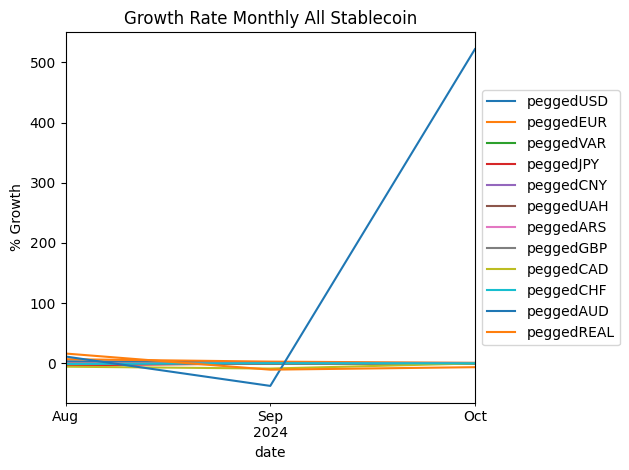

In [121]:
# Growth Rate All Stablecoin
growth_all = monthly_all.pct_change() * 100

plt.figure()
growth_all.dropna().plot()
plt.ylabel('% Growth')
plt.title('Growth Rate Monthly All Stablecoin')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

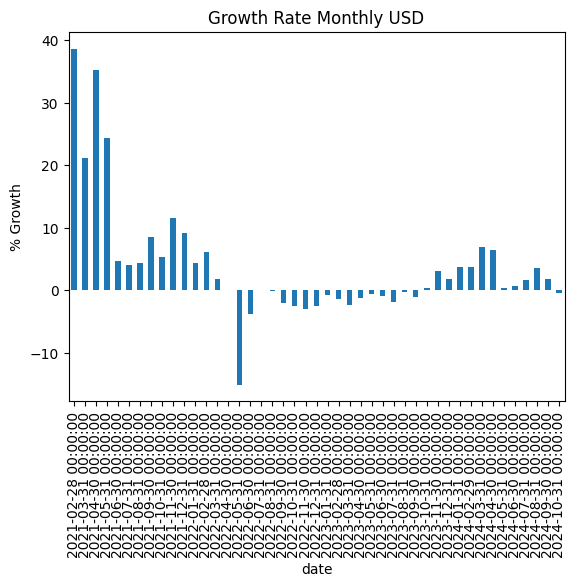

In [122]:
# Growth rate monthly
growth = monthly.pct_change().dropna() * 100
growth.plot.bar()
plt.ylabel('% Growth')
plt.title('Growth Rate Monthly USD')
plt.show()


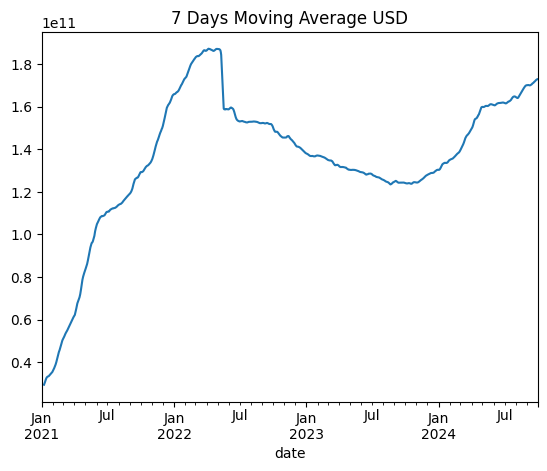

In [123]:
# 7 Days MA
df.set_index('date')['peggedUSD'].rolling(7).mean().plot()
plt.title('7 Days Moving Average USD')
plt.show()


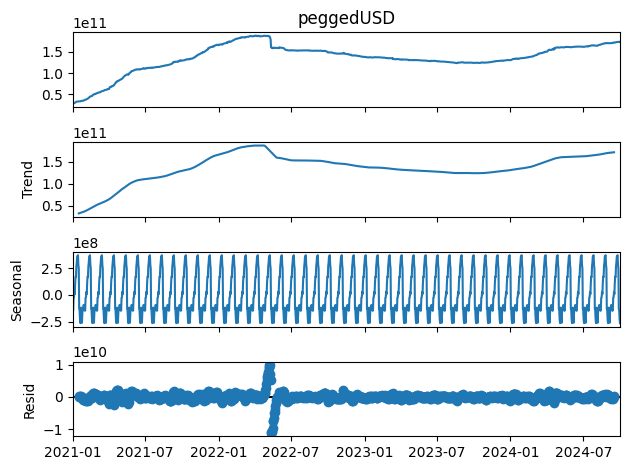

In [124]:
# Seasonal Decomposition USD
series = df.set_index('date')['peggedUSD'].dropna()
res = seasonal_decompose(series, model='additive', period=30)
res.plot()
plt.show()

# Forecasting

23:19:58 - cmdstanpy - INFO - Chain [1] start processing
23:19:58 - cmdstanpy - INFO - Chain [1] done processing


Text(0.5, 0.98, '30-Day Forecast of USD-Pegged Stablecoin Supply')

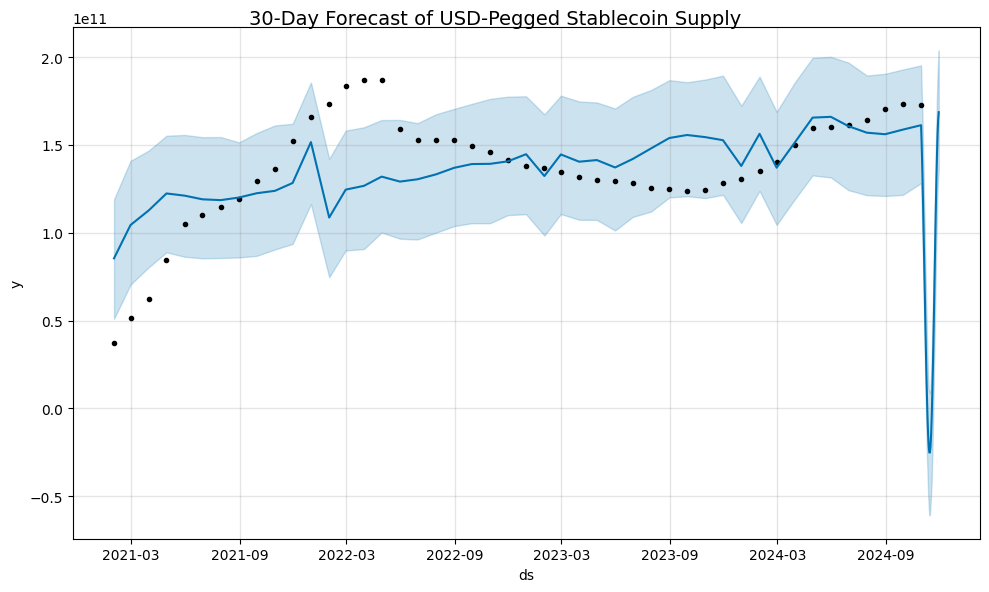

In [125]:
# 30 Days forecast
df_prophet = monthly.reset_index().rename(columns={'date':'ds','peggedUSD':'y'})
m = Prophet(); m.fit(df_prophet)
future = m.make_future_dataframe(periods=30, freq='D')
fc = m.predict(future)
fig = m.plot(fc)
fig.suptitle('30-Day Forecast of USD-Pegged Stablecoin Supply', fontsize=14)


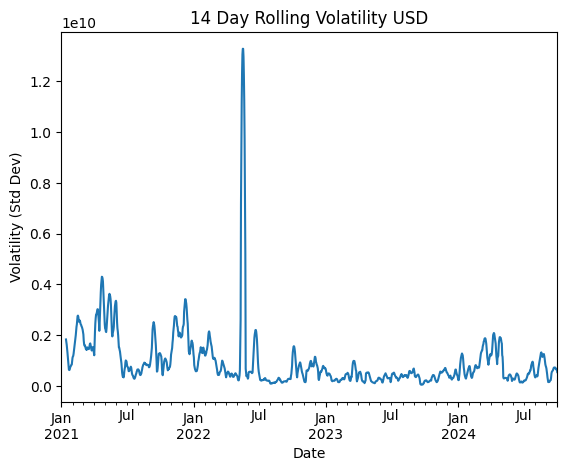

In [126]:
# 14 Day Rolling Volatility
vol = df.set_index('date')['peggedUSD'].rolling(14).std()

plt.figure()
vol.plot()
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev)')
plt.title('14 Day Rolling Volatility USD')
plt.show()

Evaluation on Test Set (last 12 months):
MAPE: 18.95%
RMSE: 34,558,035,172


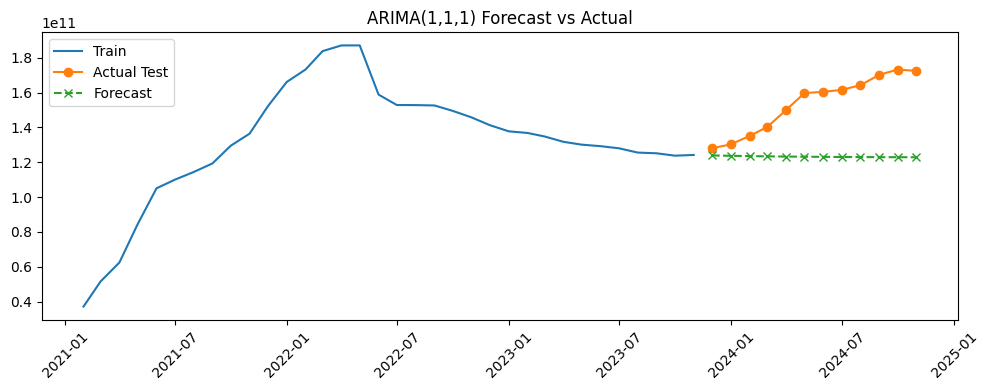

In [127]:
# Split for ARIMA
train = monthly[:-12]
test = monthly[-12:]

# Fit ARIMA(1,1,1)
model = ARIMA(train, order=(1,1,1)).fit()

# Forecast for test period
pred = model.forecast(steps=12)

# Calculate error metrics
mape = mean_absolute_percentage_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print(f"Evaluation on Test Set (last 12 months):")
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: {rmse:,.0f}")

# Plot Test vs Forecast
plt.figure(figsize=(10, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual Test')
plt.plot(pred.index, pred, 'x--', label='Forecast')
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


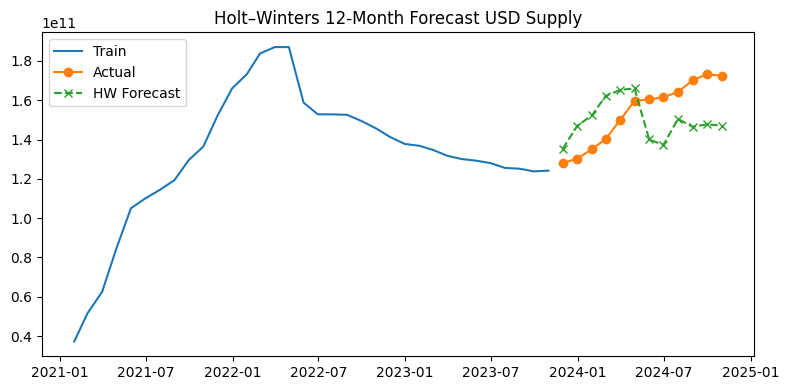

In [128]:
# Fit Holt-Winters (additive trend & seasonal)
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Forecast 12 bulan ke depan
hw_forecast = hw_model.forecast(12)

# Plot hasil
plt.figure(figsize=(8,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual')
plt.plot(hw_forecast.index, hw_forecast, 'x--', label='HW Forecast')
plt.title('Holt–Winters 12-Month Forecast USD Supply')
plt.legend()
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few obs

Best SARIMAX params: order=(0, 0, 0), seasonal_order=(2, 2, 2, 12), AIC=10.0
MAPE: 35.53%
RMSE: 61,070,460,905


/opt/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


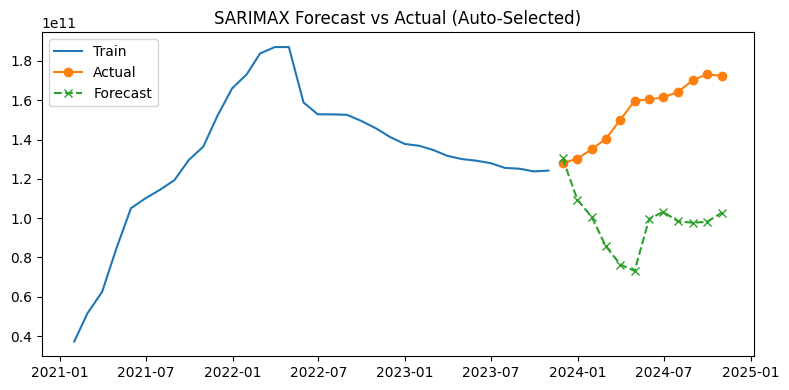

In [129]:
# Grid search for best SARIMAX(p,d,q)(P,D,Q,12) by AIC
p = d = q = range(0, 3)
pdq = [(x[0], x[1], x[2]) for x in zip(p, d, q)]
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in zip(p, d, q)]

best_aic = float('inf')
best_params = None
best_model = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            mod = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_params = (order, seasonal_order)
                best_model = res
        except Exception:
            continue

print(f"Best SARIMAX params: order={best_params[0]}, seasonal_order={best_params[1]}, AIC={best_aic:.1f}")

# Forecast with best model
forecast = best_model.get_forecast(steps=12)
pred = forecast.predicted_mean

# Compute error metrics
mape = mean_absolute_percentage_error(test, pred)
mse  = mean_squared_error(test, pred)
rmse = np.sqrt(mse)
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: {rmse:,.0f}")

# Plot actual vs forecast
plt.figure(figsize=(8, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual')
plt.plot(pred.index, pred, 'x--', label='Forecast')
plt.title('SARIMAX Forecast vs Actual (Auto-Selected)')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_62763/585744244.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').last().dropna()
23:19:59 - cmdstanpy - INFO - Chain [1] start processing
23:19:59 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


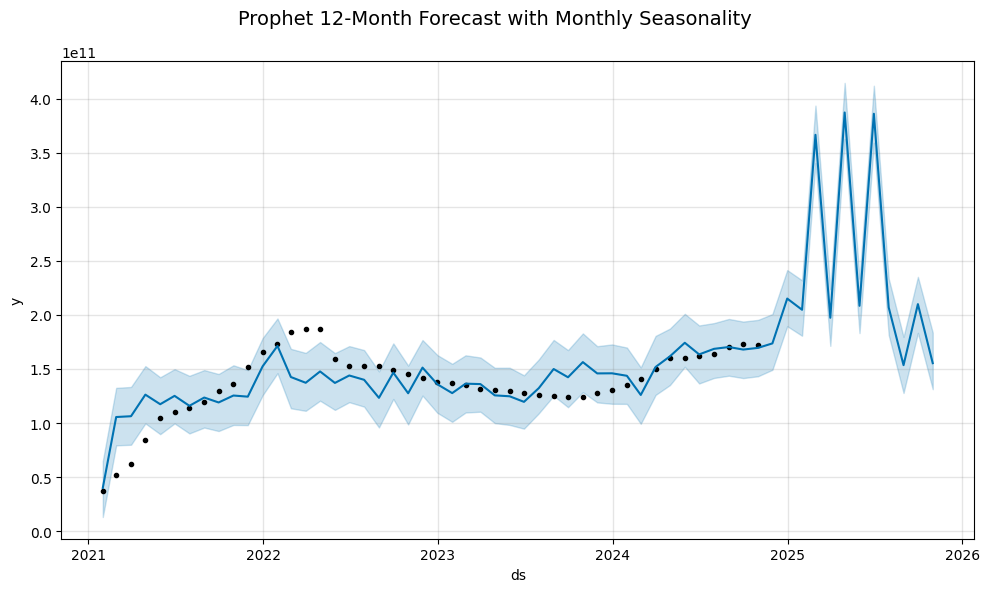

In [130]:
df_prophet = (
    df.set_index('date')['peggedUSD']
      .resample('M').last().dropna()
      .reset_index()
      .rename(columns={'date':'ds','peggedUSD':'y'})
)

m = Prophet(
    yearly_seasonality=True,      # tangkap pola tahunan
    weekly_seasonality=False,
    daily_seasonality=False
)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=12, freq='M')
fc     = m.predict(future)

fig = m.plot(fc)
fig.suptitle('Prophet 12-Month Forecast with Monthly Seasonality', fontsize=14)
plt.tight_layout()
plt.show()
